# BB84 QKD Simulator — Phase 1 Baseline
**University of Ruhuna, Dept. of Computer Engineering**

| File | Responsibility |
|---|---|
| `bb84_config.py` | Dataclasses: `SimulationConfig`, `QBERResult`, `SimulationResult` |
| `bb84_core.py` | Quantum parties: `Alice`, `Bob`, `Eve`, `QuantumChannel`; `sift_keys()`, `estimate_qber()` |
| `bb84_runner.py` | Orchestration: `run_simulation()`, `run_comparison()`, `PRESET_SCENARIOS` |
| `bb84_plots.py` | Visualisation: `plot_comparison()`, `plot_qber_vs_intercept_rate()` |

---
### What Phase 1 does NOT yet include *(planned)*
- **Phase 3** — Phase/amplitude damping, distance-based photon loss
- **Phase 4** — Entanglement-based attacks, PNS attack, decoy-state protocol
- **Phase 5** — Error correction (Cascade / LDPC), privacy amplification

## Cell 1 — Imports

In [1]:
from bb84_config import SimulationConfig
from bb84_runner import run_simulation, run_comparison, PRESET_SCENARIOS
from bb84_plots  import plot_comparison, plot_qber_vs_intercept_rate

---
## Cell 2 — Single Run: Ideal Channel

In [2]:
cfg_ideal = SimulationConfig(
    n_qubits      = 500,
    eve_present   = False,
    noise_enabled = False,
    seed          = 42,
    label         = "Ideal",
)

result_ideal = run_simulation(cfg_ideal, verbose=True)


════════════════════════════════════════════════════════════
  BB84 QKD SIMULATOR — Phase 1 Baseline
  University of Ruhuna, Dept. of Computer Engineering
════════════════════════════════════════════════════════════
  Label        : Ideal
  Qubits       : 500
  Eve Present  : False
  Noise        : False
  QBER Sample  : 10% of sifted key
  Seed         : 42
════════════════════════════════════════════════════════════

  [1/4] Quantum Transmission  (500 qubits)...
        ↳ 500/500 qubits sent ✓

  [2/4] Key Sifting (basis reconciliation)...
        ↳ 248 bits retained (49.6% — expected ~50 %)

  [3/4] QBER Estimation (sample fraction = 10%)...
        ↳ QBER   : 0.00 %  (95 % CI [0.0 %, 13.8 %])
        ↳ Errors : 0 / 24
        ↳ Status : SECURE ✓

  [4/4] Key Distillation...
        ↳ Final key : 224 bits

────────────────────────────────────────────────────────────
  RESULT SUMMARY
────────────────────────────────────────────────────────────
  Transmitted          : 500 qubits
  A

---
## Cell 3 — Single Run: Eve Full Intercept (100 %)

In [3]:
cfg_eve = SimulationConfig(
    n_qubits           = 500,
    eve_present        = True,
    eve_intercept_prob = 1.0,
    noise_enabled      = False,
    seed               = 42,
    label              = "Eve 100%",
)

result_eve = run_simulation(cfg_eve, verbose=True)


════════════════════════════════════════════════════════════
  BB84 QKD SIMULATOR — Phase 1 Baseline
  University of Ruhuna, Dept. of Computer Engineering
════════════════════════════════════════════════════════════
  Label        : Eve 100%
  Qubits       : 500
  Eve Present  : True  (intercept p = 1.0)
  Noise        : False
  QBER Sample  : 10% of sifted key
  Seed         : 42
════════════════════════════════════════════════════════════

  [1/4] Quantum Transmission  (500 qubits)...
        ↳ 500/500 qubits sent ✓

  [2/4] Key Sifting (basis reconciliation)...
        ↳ 248 bits retained (49.6% — expected ~50 %)

  [3/4] QBER Estimation (sample fraction = 10%)...
        ↳ QBER   : 20.83 %  (95 % CI [9.2 %, 40.5 %])
        ↳ Errors : 5 / 24
        ↳ Status : ABORT ✗

  [4/4] Key Distillation...
        ↳ Final key : 224 bits

────────────────────────────────────────────────────────────
  RESULT SUMMARY
────────────────────────────────────────────────────────────
  Transmitted   

---
## Cell 4 — Single Run: Depolarizing Channel Noise Only

In [4]:
cfg_noise = SimulationConfig(
    n_qubits      = 500,
    eve_present   = False,
    noise_enabled = True,
    depolar_prob  = 0.05,
    seed          = 42,
    label         = "Noise p=0.05",
)

result_noise = run_simulation(cfg_noise, verbose=True)


════════════════════════════════════════════════════════════
  BB84 QKD SIMULATOR — Phase 1 Baseline
  University of Ruhuna, Dept. of Computer Engineering
════════════════════════════════════════════════════════════
  Label        : Noise p=0.05
  Qubits       : 500
  Eve Present  : False
  Noise        : True  (depolar p = 0.05)
  QBER Sample  : 10% of sifted key
  Seed         : 42
════════════════════════════════════════════════════════════
  [Channel] Depolarizing noise  p = 0.05

  [1/4] Quantum Transmission  (500 qubits)...
        ↳ 500/500 qubits sent ✓

  [2/4] Key Sifting (basis reconciliation)...
        ↳ 248 bits retained (49.6% — expected ~50 %)

  [3/4] QBER Estimation (sample fraction = 10%)...
        ↳ QBER   : 8.33 %  (95 % CI [2.3 %, 25.8 %])
        ↳ Errors : 2 / 24
        ↳ Status : WARNING ⚠

  [4/4] Key Distillation...
        ↳ Final key : 224 bits

────────────────────────────────────────────────────────────
  RESULT SUMMARY
────────────────────────────────

---
## Cell 5 — Multi-Scenario Comparison (5 presets)

In [5]:
results = run_comparison(PRESET_SCENARIOS)


════════════════════════════════════════════════════════════
  MULTI-SCENARIO COMPARISON
════════════════════════════════════════════════════════════

  ▶  Ideal (no noise, no Eve)
     QBER = 0.0 %  │  Key = 269 bits  │  Status = SECURE ✓  │  75.6s

  ▶  Eve — Full Intercept (100 %)
     QBER = 31.0 %  │  Key = 269 bits  │  Status = ABORT ✗  │  180.9s

  ▶  Eve — Partial Intercept (50 %)
     QBER = 17.2 %  │  Key = 269 bits  │  Status = ABORT ✗  │  173.3s

  ▶  Channel Noise Only (p = 0.05)
  [Channel] Depolarizing noise  p = 0.05
     QBER = 0.0 %  │  Key = 269 bits  │  Status = SECURE ✓  │  45.9s

  ▶  Eve (100 %) + Channel Noise
  [Channel] Depolarizing noise  p = 0.05
     QBER = 20.7 %  │  Key = 269 bits  │  Status = ABORT ✗  │  96.0s

════════════════════════════════════════════════════════════


## Cell 5b — Plot the Comparison

  [✓] Saved → qkd_comparison.png


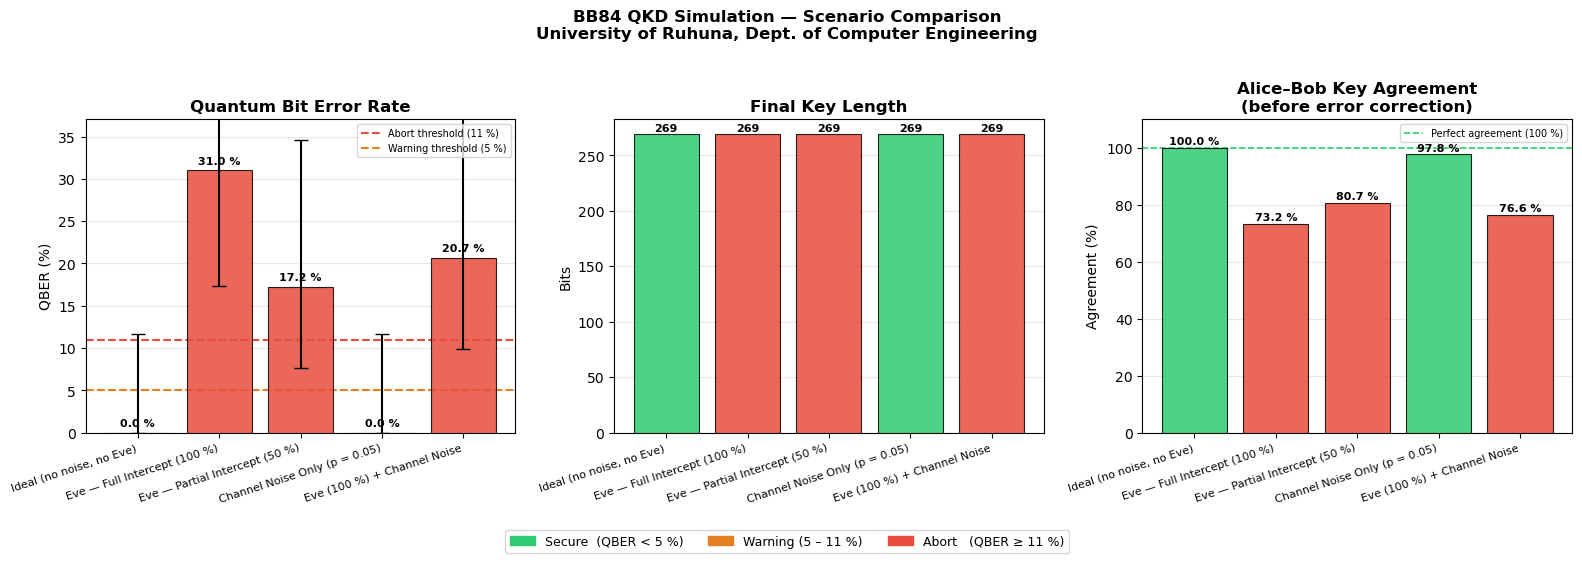

In [6]:
plot_comparison(
    scenarios = PRESET_SCENARIOS,
    results   = results,
    save_path = "qkd_comparison.png",   # set None to skip saving
)

---
## Cell 6 — Research Experiment: QBER vs Eve Intercept Rate

In [ ]:
# Sweeps Eve's intercept probability 0 % → 100 % in `steps` steps.
# Plots simulated QBER vs theoretical prediction (QBER = 0.25 × p).
plot_qber_vs_intercept_rate(
    n_qubits  = 400,
    steps     = 10,
    save_path = "qkd_qber_vs_eve.png",
)

---
## Cell 7 — Quick Access to Result Fields

In [ ]:
# Inspect any result programmatically
r = result_ideal

print(f"Transmitted      : {r.n_transmitted} qubits")
print(f"Sifted           : {r.n_sifted} bits ({r.sifted_key_rate:.1%})")
print(f"Final key length : {r.key_length} bits")
print(f"Key gen rate     : {r.key_generation_rate:.4f} bits/qubit")
print(f"QBER             : {r.qber_result.qber * 100:.2f} %")
print(f"Security status  : {r.qber_result.security_status}")
print(f"Keys match       : {r.keys_match}")
print(f"Runtime          : {r.runtime_seconds:.2f}s")

---
## Cell 8 — Custom Experiment Template
future devs

In [ ]:
my_cfg = SimulationConfig(
    n_qubits           = 800,       # ← change me
    eve_present        = True,      # ← toggle Eve
    eve_intercept_prob = 0.30,      # ← Eve intercepts 30 % of qubits
    noise_enabled      = False,     # ← toggle channel noise
    depolar_prob       = 0.02,      # ← noise level (active only if noise_enabled=True)
    sample_fraction    = 0.10,      # ← 10 % of sifted key used for QBER check
    seed               = None,      # ← None = random run
    label              = "test",
)

my_result = run_simulation(my_cfg, verbose=True)